In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

sns.set_theme(style="whitegrid")

In [2]:
PROJECT_ROOT = Path("..")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

print("Project root:", PROJECT_ROOT.resolve())
print("Processed data path:", DATA_PROCESSED.resolve())

Project root: /workspaces/potential-pathway-index
Processed data path: /workspaces/potential-pathway-index/data/processed


In [3]:
modeling_dataset_path = DATA_PROCESSED / "early_behavior_dataset.csv"

print("Modeling dataset path:")
print(modeling_dataset_path)

print("\nFile exists:")
print(modeling_dataset_path.exists())

Modeling dataset path:
../data/processed/early_behavior_dataset.csv

File exists:
True


In [4]:
modeling_dataset = pd.read_csv(modeling_dataset_path)

print("modeling_dataset loaded successfully.")
print("Shape:", modeling_dataset.shape)

modeling_dataset.head()

modeling_dataset loaded successfully.
Shape: (32593, 39)


,id_student,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,max_score_30d,total_assessment_weight_30d,late_submission_count_30d,avg_days_late_30d,max_days_late_30d,first_submission_day_30d,last_submission_day_30d,banked_submissions_30d,has_assessment_submission_30d,has_assessment_score_30d
0,11391,AAA,2013J,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,78.0,10.0,0.0,0.0,0.0,18.0,18.0,0.0,1,1
1,28400,AAA,2013J,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,70.0,10.0,1.0,3.0,3.0,22.0,22.0,0.0,1,1
2,30268,AAA,2013J,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,-1.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0,0
3,31604,AAA,2013J,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,72.0,10.0,0.0,0.0,0.0,17.0,17.0,0.0,1,1
4,32885,AAA,2013J,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,69.0,10.0,1.0,7.0,7.0,26.0,26.0,0.0,1,1


In [5]:
main_keys = ["id_student", "code_module", "code_presentation"]

total_rows = modeling_dataset.shape[0]
unique_keys = modeling_dataset[main_keys].drop_duplicates().shape[0]

print("Total rows:", total_rows)
print("Unique student-module-presentation keys:", unique_keys)
print("Is the main key unique?", total_rows == unique_keys)

Total rows: 32593
Unique student-module-presentation keys: 32593
Is the main key unique? True


In [6]:
target_summary = pd.DataFrame({
    "count": modeling_dataset["at_risk_misalignment"].value_counts().sort_index(),
    "percentage": (
        modeling_dataset["at_risk_misalignment"].value_counts(normalize=True).sort_index() * 100
    ).round(2)
})

target_summary

,count,percentage
at_risk_misalignment,,
0,15385,47.2
1,17208,52.8


In [7]:
target_column = "at_risk_misalignment"

excluded_columns = [
    "id_student",
    "final_result",
    target_column
]

print("Target column:")
print(target_column)

print("\nExcluded columns:")
print(excluded_columns)

Target column:
at_risk_misalignment

Excluded columns:
['id_student', 'final_result', 'at_risk_misalignment']


In [8]:
X = modeling_dataset.drop(columns=excluded_columns)
y = modeling_dataset[target_column]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

X.head()

Feature matrix shape: (32593, 36)
Target vector shape: (32593,)


,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,...,max_score_30d,total_assessment_weight_30d,late_submission_count_30d,avg_days_late_30d,max_days_late_30d,first_submission_day_30d,last_submission_day_30d,banked_submissions_30d,has_assessment_submission_30d,has_assessment_score_30d
0,AAA,2013J,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,...,78.0,10.0,0.0,0.0,0.0,18.0,18.0,0.0,1,1
1,AAA,2013J,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,...,70.0,10.0,1.0,3.0,3.0,22.0,22.0,0.0,1,1
2,AAA,2013J,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,...,-1.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0,0
3,AAA,2013J,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,...,72.0,10.0,0.0,0.0,0.0,17.0,17.0,0.0,1,1
4,AAA,2013J,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,...,69.0,10.0,1.0,7.0,7.0,26.0,26.0,0.0,1,1


In [9]:
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Number of numerical features:", len(numerical_features))
print(numerical_features)

print("\nNumber of categorical features:", len(categorical_features))
print(categorical_features)

Number of numerical features: 28
['num_of_prev_attempts', 'studied_credits', 'date_registration', 'total_clicks_30d', 'active_days_30d', 'avg_clicks_per_active_day_30d', 'max_clicks_single_day_30d', 'std_clicks_active_day_30d', 'first_activity_day_30d', 'last_activity_day_30d', 'activity_span_30d', 'days_since_last_activity_30d', 'has_vle_activity_30d', 'submitted_assessments_30d', 'scored_assessments_30d', 'missing_score_submissions_30d', 'avg_score_30d', 'min_score_30d', 'max_score_30d', 'total_assessment_weight_30d', 'late_submission_count_30d', 'avg_days_late_30d', 'max_days_late_30d', 'first_submission_day_30d', 'last_submission_day_30d', 'banked_submissions_30d', 'has_assessment_submission_30d', 'has_assessment_score_30d']

Number of categorical features: 8
['code_module', 'code_presentation', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']


/tmp/ipykernel_16709/2692315652.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


In [10]:
numerical_missing = X[numerical_features].isnull().sum()
numerical_missing = numerical_missing[numerical_missing > 0].sort_values(ascending=False)

print("Numerical features with missing values:")
print(numerical_missing)

# Check missing values in categorical features.
categorical_missing = X[categorical_features].isnull().sum()
categorical_missing = categorical_missing[categorical_missing > 0].sort_values(ascending=False)

print("\nCategorical features with missing values:")
print(categorical_missing)

Numerical features with missing values:
date_registration    45
dtype: int64

Categorical features with missing values:
imd_band    1111
dtype: int64


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (26074, 36)
X_test shape: (6519, 36)
y_train shape: (26074,)
y_test shape: (6519,)


In [12]:
train_target_distribution = y_train.value_counts(normalize=True).sort_index() * 100
test_target_distribution = y_test.value_counts(normalize=True).sort_index() * 100

target_split_summary = pd.DataFrame({
    "train_percentage": train_target_distribution.round(2),
    "test_percentage": test_target_distribution.round(2)
})

target_split_summary

,train_percentage,test_percentage
at_risk_misalignment,,
0,47.2,47.2
1,52.8,52.8


In [14]:
numerical_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

print("Numerical preprocessor created successfully.")

Numerical preprocessor created successfully.


In [15]:
categorical_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

print("Categorical preprocessor created successfully.")

Categorical preprocessor created successfully.


In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_preprocessor, numerical_features),
        ("cat", categorical_preprocessor, categorical_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [17]:
numerical_features = X.select_dtypes(include=["number"]).columns.tolist()

categorical_features = [
    column for column in X.columns 
    if column not in numerical_features
]

print("Number of numerical features:", len(numerical_features))
print(numerical_features)

print("\nNumber of categorical features:", len(categorical_features))
print(categorical_features)

Number of numerical features: 28
['num_of_prev_attempts', 'studied_credits', 'date_registration', 'total_clicks_30d', 'active_days_30d', 'avg_clicks_per_active_day_30d', 'max_clicks_single_day_30d', 'std_clicks_active_day_30d', 'first_activity_day_30d', 'last_activity_day_30d', 'activity_span_30d', 'days_since_last_activity_30d', 'has_vle_activity_30d', 'submitted_assessments_30d', 'scored_assessments_30d', 'missing_score_submissions_30d', 'avg_score_30d', 'min_score_30d', 'max_score_30d', 'total_assessment_weight_30d', 'late_submission_count_30d', 'avg_days_late_30d', 'max_days_late_30d', 'first_submission_day_30d', 'last_submission_day_30d', 'banked_submissions_30d', 'has_assessment_submission_30d', 'has_assessment_score_30d']

Number of categorical features: 8
['code_module', 'code_presentation', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']


In [18]:
baseline_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

print("Baseline models defined successfully.")
print(list(baseline_models.keys()))

Baseline models defined successfully.
['Logistic Regression', 'Decision Tree', 'Random Forest']


In [19]:
model_pipelines = {}

for model_name, model in baseline_models.items():
    model_pipelines[model_name] = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

print("Model pipelines created successfully.")
print(list(model_pipelines.keys()))

Model pipelines created successfully.
['Logistic Regression', 'Decision Tree', 'Random Forest']


In [20]:
trained_models = {}

for model_name, pipeline in model_pipelines.items():
    print(f"Training model: {model_name}")
    
    pipeline.fit(X_train, y_train)
    trained_models[model_name] = pipeline
    
    print(f"{model_name} trained successfully.\n")

Training model: Logistic Regression
Logistic Regression trained successfully.

Training model: Decision Tree
Decision Tree trained successfully.

Training model: Random Forest
Random Forest trained successfully.



In [21]:
def evaluate_model(model_name, model_pipeline, X_test, y_test):
    """
    Evaluates a trained classification pipeline on the test set.
    
    Returns:
    A dictionary with key classification metrics.
    """
    
    # Predict classes.
    y_pred = model_pipeline.predict(X_test)
    
    # Predict probabilities for ROC-AUC.
    y_proba = model_pipeline.predict_proba(X_test)[:, 1]
    
    metrics = {
        "model_name": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba)
    }
    
    return metrics

In [22]:
model_results = []

for model_name, trained_pipeline in trained_models.items():
    metrics = evaluate_model(
        model_name=model_name,
        model_pipeline=trained_pipeline,
        X_test=X_test,
        y_test=y_test
    )
    
    model_results.append(metrics)

model_results_df = pd.DataFrame(model_results)

# Sort models by recall first, then ROC-AUC.
model_results_df = model_results_df.sort_values(
    by=["recall", "roc_auc"],
    ascending=False
)

model_results_df

,model_name,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.764841,0.817849,0.713539,0.762141,0.843699
1,Decision Tree,0.751496,0.808395,0.693783,0.746717,0.831269
2,Random Forest,0.769597,0.845934,0.689134,0.759526,0.852793


In [23]:
for model_name, trained_pipeline in trained_models.items():
    print("=" * 80)
    print(f"Classification Report: {model_name}")
    print("=" * 80)
    
    y_pred = trained_pipeline.predict(X_test)
    
    print(classification_report(y_test, y_pred))

Classification Report: Logistic Regression
              precision    recall  f1-score   support

           0       0.72      0.82      0.77      3077
           1       0.82      0.71      0.76      3442

    accuracy                           0.76      6519
   macro avg       0.77      0.77      0.76      6519
weighted avg       0.77      0.76      0.76      6519

Classification Report: Decision Tree
              precision    recall  f1-score   support

           0       0.70      0.82      0.76      3077
           1       0.81      0.69      0.75      3442

    accuracy                           0.75      6519
   macro avg       0.76      0.75      0.75      6519
weighted avg       0.76      0.75      0.75      6519

Classification Report: Random Forest
              precision    recall  f1-score   support

           0       0.71      0.86      0.78      3077
           1       0.85      0.69      0.76      3442

    accuracy                           0.77      6519
   macro av

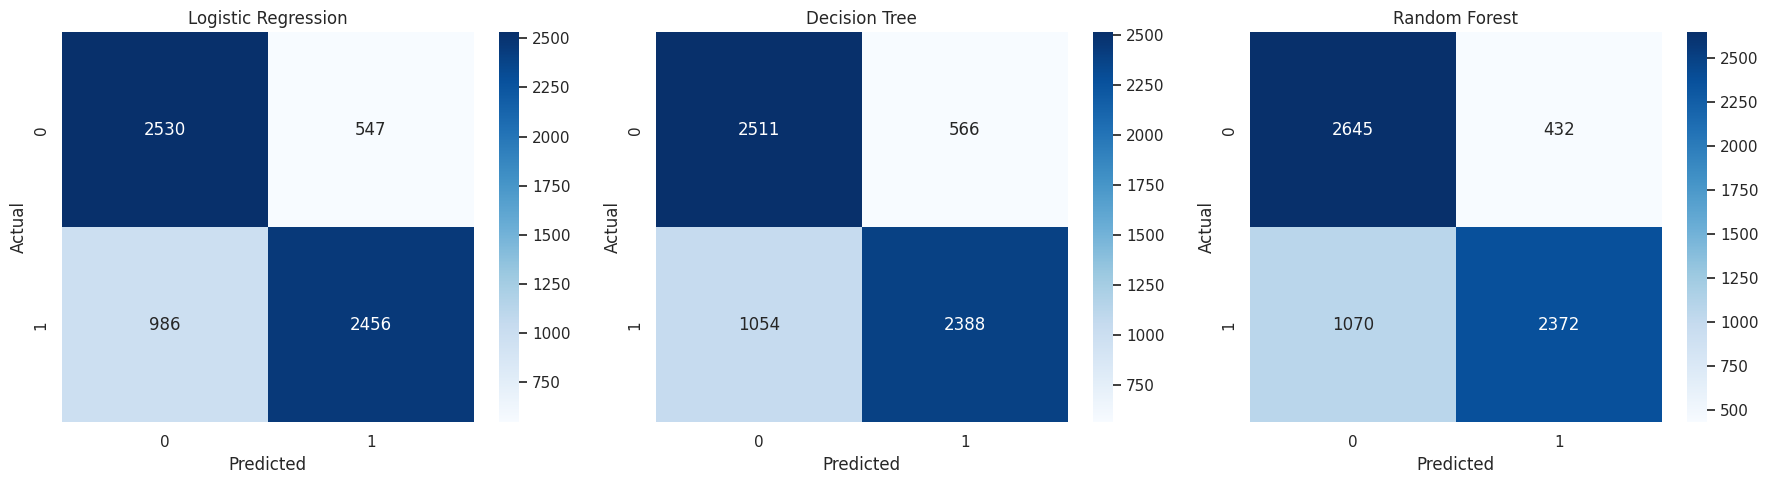

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for index, (model_name, trained_pipeline) in enumerate(trained_models.items()):
    y_pred = trained_pipeline.predict(X_test)
    matrix = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[index]
    )
    
    axes[index].set_title(model_name)
    axes[index].set_xlabel("Predicted")
    axes[index].set_ylabel("Actual")

plt.tight_layout()
plt.show()